In [ ]:
!python -m spacy download pl_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 41.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("pl_core_news_sm")

In [ ]:
import pandas as pd
import re

Ustawienie Pandas, aby wypisywało WSZYSTKIE wiersze (bez ucinania ...)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [ ]:
#sprowadzenie nazwiska (np. dziecka/matki/ojca) do wspólnej formy męskiej/rodzinnej
def normalize_father_surname(name):
    if not name or name == "Brak": return name

    #normalizacja płciowa (ska, cka, dzka -> i)
    if name.endswith(('ska', 'cka', 'dzka')): return name[:-1] + 'i'

    #usuwanie archaicznych końcówek przymiotnikowych (-iey, -ey -> y)
    if name.endswith('iey'): return name[:-3] + 'y'
    if name.endswith('ey'): return name[:-2] + 'y'
    return name

In [ ]:
def normalize_maiden_name(s):
    if not s or s == "Brak": return s
    s_lower = s.lower().strip()

    #obsługa końcówek -iey / -ey (np. Barańskiey -> Barańska)
    s_lower = re.sub(r'iey$|ey$', 'a', s_lower)

    #obsługa końcówek -ówny / -anki (oznaczających pannę/córkę)
    s_lower = re.sub(r'ówny$|owny$|ówna$|owna$', 'ówna', s_lower)
    s_lower = re.sub(r'anki$|anka$', 'anka', s_lower)

    #inne archaiczne końcówki
    s_lower = re.sub(r'ionki$|ionka$|onki$|onka$', 'a', s_lower)

    #obsługa końcówek -ową / -owa (często przy mężatkach/wdowach, np. Dziubkową -> Dziubkowa)
    s_lower = re.sub(r'ową$|owa$', 'owa', s_lower)
    return s_lower.capitalize()

In [ ]:
with open('ksiega.txt', 'r', encoding='utf-8') as f:
    full_text = f.read()

In [ ]:
acts = re.split(r'Akt nr (\d+)', full_text)
parsed_records = []

for i in range(1, len(acts), 2):
    nr_aktu = acts[i]
    content = acts[i+1].replace('\n', ' ')

    #ekstrakcja dziecka
    dziecko_match = re.search(r'\((.*?)\)', content)
    imie_dziecka = dziecko_match.group(1).split()[0] if dziecko_match else "Brak"
    nazwisko_raw = dziecko_match.group(1).split()[-1] if dziecko_match else "Brak"

    #płeć
    plec = "K" if any(x in content.lower() for x in ["żeń", "żeńsk"]) else "M"

    #miesiac
    miesiac_match = re.search(r'Miesiąca (\w+)', content, re.I)
    miesiac = miesiac_match.group(1).capitalize() if miesiac_match else "Nieznany"

    #miejscowość
    m_match = re.search(r'w (?:Wsi|Mieście|Przedmieściu Miasta|Przedmiesciu Miasta)\s+([\w\s]+?)\s+zamieszkał', content, re.I)
    miejscowosc_raw = m_match.group(1).strip() if m_match else "Olkusz"

    #zawód + Lematyzacja (NLP)
    z_pattern = r'(półrolnik|potrolnik|pulrolnik|zagrodnik|wyrobnik|komornik|mieszczanin|obywatel|leśny|leśniczy|profesor|burmistrz|starozakonny|karczmarz|szewc|kowal|garncarz|sołtys|służący|chałupnik|tkacz|rzeźnik|majster kunsztu [\w]+)'
    zawod_match = re.search(z_pattern, content, re.I)
    raw_zawod = zawod_match.group(1).lower() if zawod_match else "inny/brak"

    #lematyzacja zawodów przez spaCy
    zawod_lem = " ".join([token.lemma_ for token in nlp(raw_zawod)])
    zawod_lem = zawod_lem.replace('potrolnik', 'półrolnik').replace('pulrolnik', 'półrolnik').replace('obywatel', 'mieszczanin')

    #matka (poprawka na "wdowa", "panna")
    matka_block = re.search(r'(?:z Niego i|z Panny|z Wdowy|z niey|z teyże|z Matki)\s+(.*?)\s+(?:liczą|maią|mają|iego Małżonki|Żony|zamieszkał)', content, re.I)
    nazwisko_matki_raw = "Brak"
    if matka_block:
        m_text = re.sub(r'\b(Wdowy|Wdową|Panny|Panną|z Pławców|z)\b', '', matka_block.group(1), flags=re.I).strip()
        m_parts = m_text.split()
        if m_parts:
            potencjalne = m_parts[-2] if m_parts[-1].lower() in ['iego', 'jego'] else m_parts[-1]
            if potencjalne[0].isupper(): nazwisko_matki_raw = potencjalne

    parsed_records.append({
        "Nr_Aktu": nr_aktu, "Imie_Dziecka": imie_dziecka,
        "Nazwisko_Rodziny": normalize_father_surname(nazwisko_raw),
        "Plec": plec, "Miesiac": miesiac, "Zawod": zawod_lem,
        "Nazwisko_Matki": normalize_maiden_name(nazwisko_matki_raw),
        "Miejscowosc": miejscowosc_raw,
        "Tresc_Raw": content
    })

df = pd.DataFrame(parsed_records)

In [ ]:
loc_map = {'Olkuszu': 'Olkusz', 'Żuradzie': 'Żurada', 'Pomorzanach': 'Pomorzany', 'Kluczach': 'Klucze',
           'Witeradowie': 'Witeradów', 'Ujkowie': 'Ujków', 'Bogucinie': 'Bogucin', 'Czarney Górze': 'Czarna Góra'}
df['Miejscowosc_Clean'] = df['Miejscowosc'].replace(loc_map)

m_order = ['Stycznia', 'Lutego', 'Marca', 'Kwietnia', 'Maja', 'Czerwca', 'Lipca', 'Sierpnia', 'Września', 'Października', 'Listopada', 'Grudnia']
df['Miesiac'] = pd.Categorical(df['Miesiac'], categories=m_order, ordered=True)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

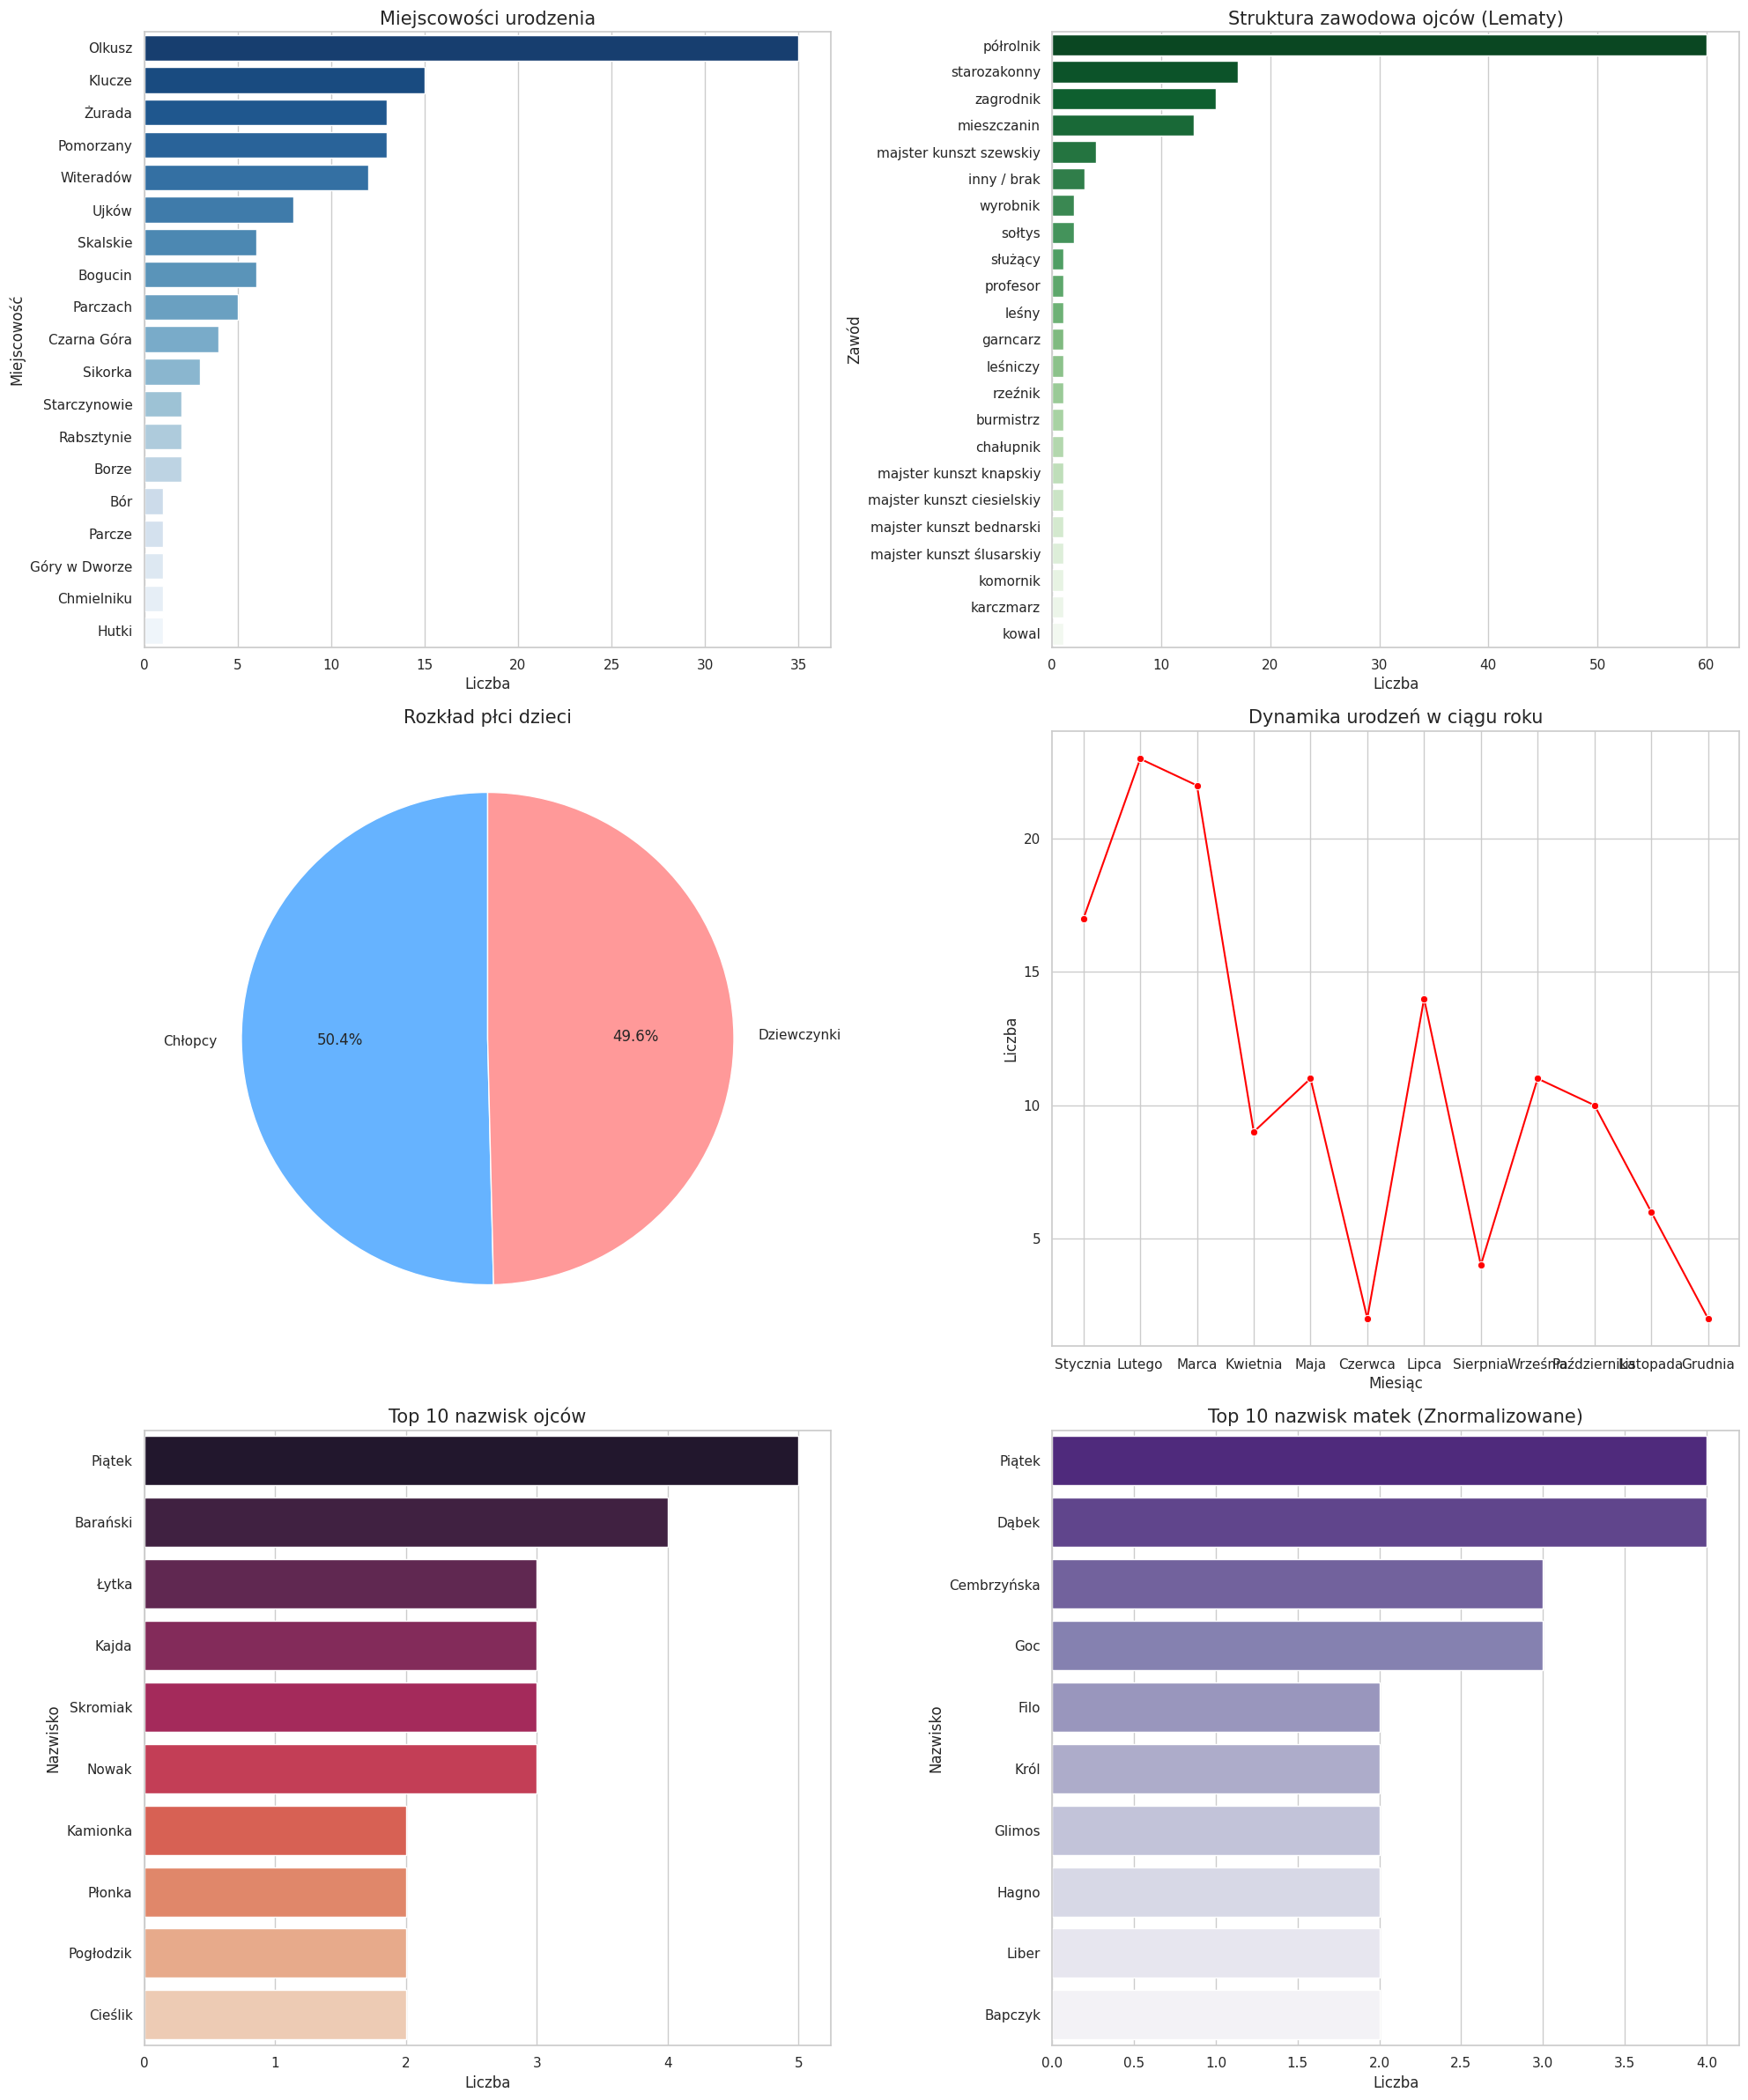

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(20, 24))

#miejscowości
order_m = df['Miejscowosc_Clean'].value_counts().index
sns.countplot(data=df, y='Miejscowosc_Clean', order=order_m, ax=axes[0,0],
              palette="Blues_r", hue='Miejscowosc_Clean', hue_order=order_m, legend=False)
axes[0,0].set_title('Miejscowości urodzenia', fontsize=15)
axes[0,0].set_xlabel('Liczba'); axes[0,0].set_ylabel('Miejscowość')

#zawody
df_z = df[df['Zawod'] != 'inny/brak']
order_z = df_z['Zawod'].value_counts().index
sns.countplot(data=df_z, y='Zawod', order=order_z, ax=axes[0,1],
              palette="Greens_r", hue='Zawod', hue_order=order_z, legend=False)
axes[0,1].set_title('Struktura zawodowa ojców (Lematy)', fontsize=15)
axes[0,1].set_xlabel('Liczba'); axes[0,1].set_ylabel('Zawód')

#płeć
df['Plec'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1,0], colors=['#66b3ff','#ff9999'],
                                   labels=['Chłopcy', 'Dziewczynki'], startangle=90)
axes[1,0].set_title('Rozkład płci dzieci', fontsize=15)
axes[1,0].set_ylabel('')

#dynamika
counts_m = df['Miesiac'].value_counts().sort_index()
sns.lineplot(x=counts_m.index, y=counts_m.values, marker='o', ax=axes[1,1], color='red')
axes[1,1].set_title('Dynamika urodzeń w ciągu roku', fontsize=15)
axes[1,1].set_xlabel('Miesiąc'); axes[1,1].set_ylabel('Liczba')

#top 10 nazwisk ojców
order_n_o = df['Nazwisko_Rodziny'].value_counts().head(10).index
sns.barplot(x=df['Nazwisko_Rodziny'].value_counts().head(10).values, y=order_n_o,
            ax=axes[2,0], palette="rocket", hue=order_n_o, hue_order=order_n_o, legend=False)
axes[2,0].set_title('Top 10 nazwisk ojców', fontsize=15)
axes[2,0].set_xlabel('Liczba'); axes[2,0].set_ylabel('Nazwisko')

#top 10 nazwisk matek
df_m = df[df['Nazwisko_Matki'] != 'Brak']
order_n_m = df_m['Nazwisko_Matki'].value_counts().head(10).index
sns.barplot(x=df_m['Nazwisko_Matki'].value_counts().head(10).values, y=order_n_m,
            ax=axes[2,1], palette="Purples_r", hue=order_n_m, hue_order=order_n_m, legend=False)
axes[2,1].set_title('Top 10 nazwisk matek (Znormalizowane)', fontsize=15)
axes[2,1].set_xlabel('Liczba'); axes[2,1].set_ylabel('Nazwisko')

plt.tight_layout()
plt.show()

In [ ]:
from wordcloud import WordCloud

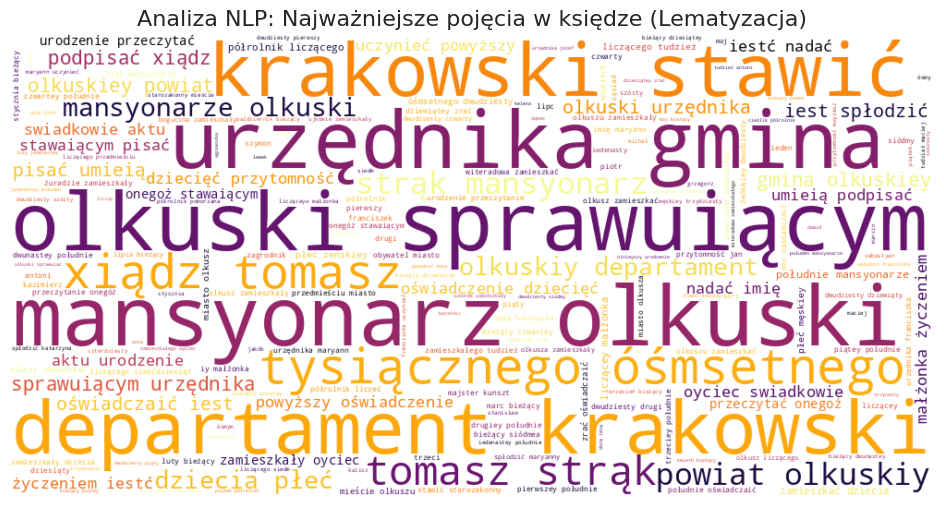

In [ ]:
#stopwords
stop = {'rok', 'dzień', 'miesiąc', 'godzina', 'rano', 'wieczór', 'przed', 'tysiączny', 'óśmsetny', 'dwunasty', 'akt', 'numer', 'nam', 'stawił', 'okazać', 'liczący', 'stan', 'cywilny', 'urzędnik', 'sprawuiący', 'obowiązki', 'gminy', 'lat', 'dom', 'urodzić'}
lemmas = []

#nlp.pipe dla szybkości
for doc in nlp.pipe(df['Tresc_Raw'], disable=["ner", "parser"]):
    lemmas.extend([t.lemma_.lower() for t in doc if not t.is_stop and not t.is_punct and not t.like_num and len(t.text) > 3 and t.lemma_.lower() not in stop])

plt.figure(figsize=(12, 6))
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='inferno').generate(" ".join(lemmas))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Analiza NLP: Najważniejsze pojęcia w księdze (Lematyzacja)", fontsize=16)
plt.show()

In [ ]:
print("PEŁNY RAPORT LICZBOWY - PARAFIA OLKUSZ 1812")

print("\n1. PŁEĆ DZIECI (Dokładne ilości):")
print(df['Plec'].value_counts().to_string())

print("\n2. MIEJSCOWOŚCI (Wszystkie):")
print(df['Miejscowosc_Clean'].value_counts().to_string())

print("\n3. ZAWODY OJCÓW (Wszystkie - Lematy):")
print(df['Zawod'].value_counts().to_string())

print("\n4. DYNAMIKA URODZEŃ (Miesiące):")
print(df['Miesiac'].value_counts().sort_index().to_string())

print("\n5. NAZWISKA RODZINNE (Wszystkie znormalizowane):")
print(df['Nazwisko_Rodziny'].value_counts().sort_index().to_string())

print("\n6. NAZWISKA PANIEŃSKIE MATEK (Wszystkie znormalizowane):")
print(df[df['Nazwisko_Matki'] != 'Brak']['Nazwisko_Matki'].value_counts().sort_index().to_string())

print("\n7. NAJCZĘSTSZE IMIONA DZIECI (Wszystkie):")
print(df['Imie_Dziecka'].value_counts().to_string())



PEŁNY RAPORT LICZBOWY - PARAFIA OLKUSZ 1812

1. PŁEĆ DZIECI (Dokładne ilości):
Plec
M    66
K    65

2. MIEJSCOWOŚCI (Wszystkie):
Miejscowosc_Clean
Olkusz           35
Klucze           15
Żurada           13
Pomorzany        13
Witeradów        12
Ujków             8
Skalskie          6
Bogucin           6
Parczach          5
Czarna Góra       4
Sikorka           3
Starczynowie      2
Rabsztynie        2
Borze             2
Bór               1
Parcze            1
Góry w Dworze     1
Chmielniku        1
Hutki             1

3. ZAWODY OJCÓW (Wszystkie - Lematy):
Zawod
półrolnik                     60
starozakonny                  17
zagrodnik                     15
mieszczanin                   13
majster kunszt szewskiy        4
inny / brak                    3
wyrobnik                       2
sołtys                         2
służący                        1
profesor                       1
leśny                          1
garncarz                       1
leśniczy                       